****Statistical Data Analysis****

In [4]:
import pandas as pd
import numpy as np
import sklearn
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [6]:
import lightgbm as lgb

In [25]:
df = pd.read_json("../data/train.json")
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [26]:
df_upd = df[['bathrooms','bedrooms', 'interest_level', 'price']].copy()
df_upd.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


*Target analysis*

a)Plot a histogram to understand the distribution of the target. Is it all clear?

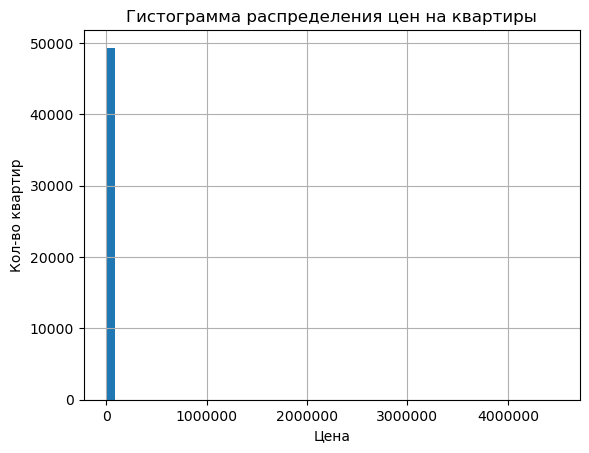

In [63]:
df_upd["price"].hist(bins = 50)
plt.title('Гистограмма распределения цен на квартиры')
plt.xlabel('Цена')
plt.ylabel('Кол-во квартир')
plt.ticklabel_format(style='plain', useOffset=False)
plt.show()

Гистограмма выглядит странно, возможно, из-за выбросов. Есть небольшое колиечство дорогих квартир

b)The next step is boxplot(). What can you say about the target? Are there any outliers?

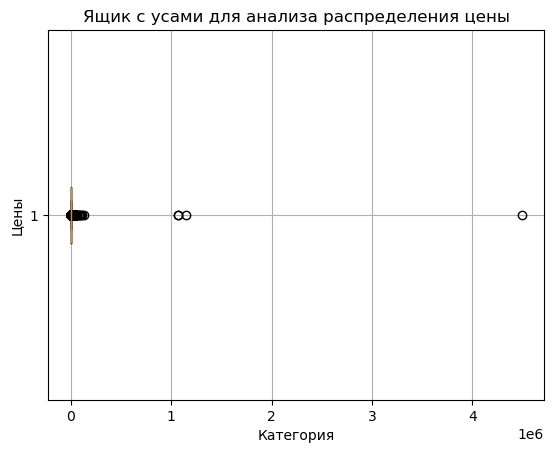

In [65]:
plt.boxplot(df_upd["price"], vert = False)
plt.title("Ящик с усами для анализа распределения цены")
plt.ylabel("Цены")
plt.xlabel("Категория")
plt.grid(True)
plt.show()

Да, посмотрев на боксплот, можно понять, что имеются выбросы в верхней части

Еще смотря где находится медиана, можно сделать вывод, что много квартир, которые достаточно дешевые.

можно ограничить ось ординат, чтобы посмотреть поближе ящик сам 

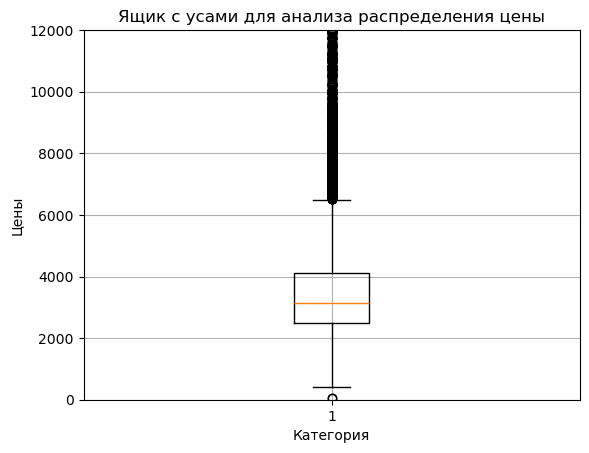

In [68]:
plt.boxplot(df_upd["price"])
plt.title("Ящик с усами для анализа распределения цены")
plt.ylabel("Цены")
plt.xlabel("Категория")
plt.ylim(0,12000)
plt.grid(True)
plt.show()

IQR сверху шире, чем снизу после медианы. Значит, цены выше медианы менее стабильные, то есть их все же меньше(дорогих квартир), чем квартир дешевле.

c)Drop the rows that are outside the 1 and 99 percentiles from the target column.

In [112]:
upper = df_upd["price"].quantile(0.99)
lower = df_upd["price"].quantile(0.01)

df_no_outliers = df_upd[(df_upd["price"] < upper) & (df_upd["price"] > lower)].copy()

In [113]:
df_upd["price"].describe(percentiles=[0.01, 0.99])

count    4.935200e+04
mean     3.830174e+03
std      2.206687e+04
min      4.300000e+01
1%       1.475000e+03
50%      3.150000e+03
99%      1.300000e+04
max      4.490000e+06
Name: price, dtype: float64

это значит, что 1% квартир стоят меньше 1475, а 99% квартир стоят меньше $$13000

d)Plot another histogram for price. Explain the result.

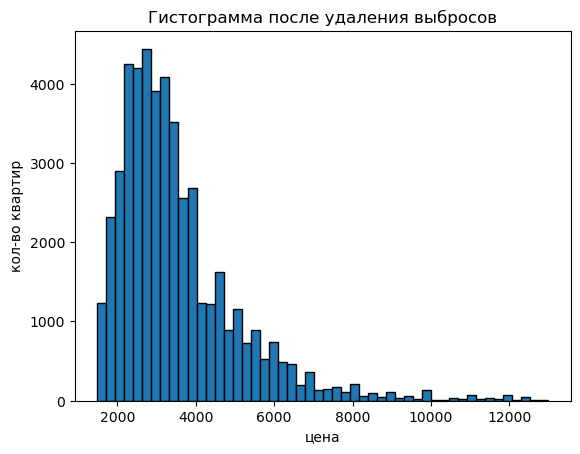

In [114]:
df_no_outliers["price"].hist(bins=50, edgecolor = "black")
plt.title("Гистограмма после удаления выбросов")
plt.xlabel("цена")
plt.ylabel("кол-во квартир")
plt.grid(False)
plt.show()

Распределение нормальное, смещен к левому краю. Данные стали более однородными после удаления выбросов. Большинство квартир стоит от 2500 до 5000.

*Characteristics Analysis*

a)What is the type of column 'interest_level'? - Ответ: Object

In [115]:
df_no_outliers.dtypes


bathrooms         float64
bedrooms            int64
interest_level     object
price               int64
dtype: object

In [116]:
df_no_outliers['interest_level'].dtype

dtype('O')

b)Print the values in this column. How many entries does each value contain?

In [117]:
df_no_outliers['interest_level'].unique()

array(['medium', 'low', 'high'], dtype=object)

In [118]:
df_no_outliers['interest_level'].value_counts()

interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

c)Encode these values. For example, you can replace each value with 0, 1, or 2.

In [119]:
df_no_outliers['interest_level'] = df_no_outliers['interest_level'].map({'low': 0, 'medium': 1, 'high': 2})

In [121]:
df_no_outliers['interest_level'].unique()

array([1, 0, 2])

In [122]:
df_no_outliers['interest_level'].value_counts()

interest_level
0    33672
1    11114
2     3557
Name: count, dtype: int64

d)Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers? - Ответ: Нет, никаких выбросов.

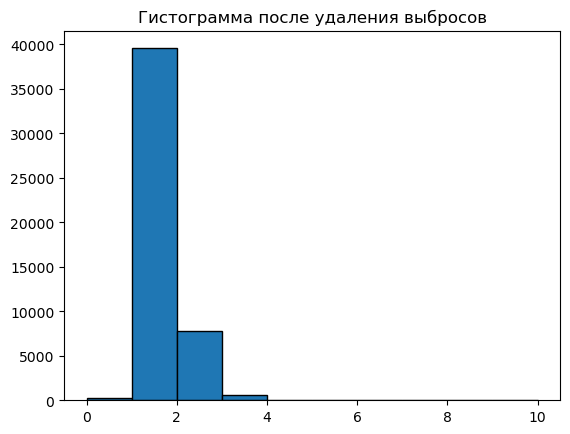

In [128]:
df_no_outliers["bathrooms"].hist(edgecolor = "black")

plt.xlabel("кол-во ванных")
plt.ylabel("кол-во квартир")
plt.grid(False)
plt.show()

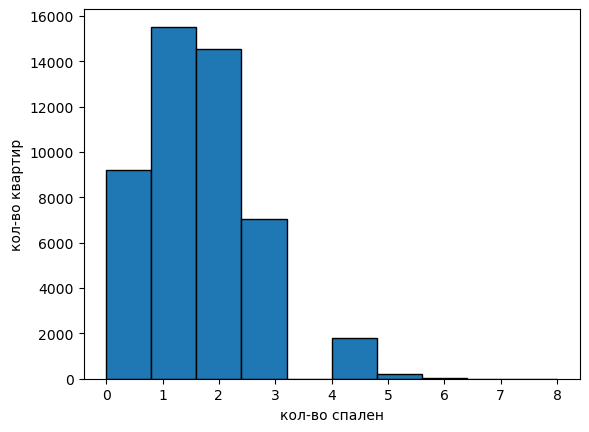

In [129]:
df_no_outliers["bedrooms"].hist(edgecolor = "black")
plt.xlabel("кол-во спален")
plt.ylabel("кол-во квартир")
plt.grid(False)
plt.show()

*Complex analysis*

a)Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. 

In [130]:
df_no_outliers.corr(numeric_only=True)

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


<Axes: >

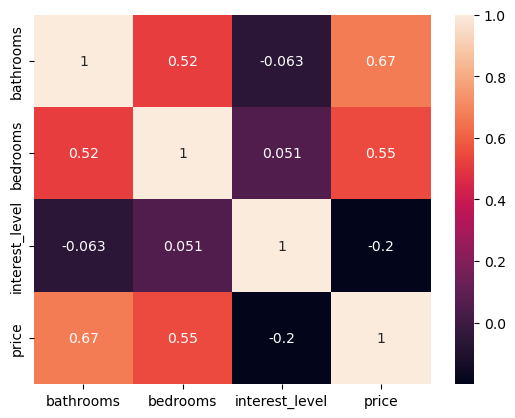

In [133]:
sns.heatmap(df_no_outliers.corr(numeric_only=True), annot = True)

b)Is there a correlation?

Наибольшая корреляция между ценой и ее признаками это bathrooms, далее bedrooms

c)Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

Text(0.5, 0, 'price')

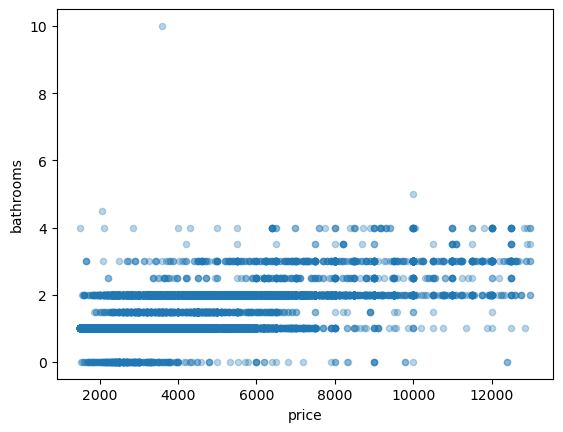

In [142]:
df_no_outliers.plot.scatter(x='price', y='bathrooms',alpha=0.3)
plt.ylabel("bathrooms")
plt.xlabel("price")

Text(0.5, 0, 'price')

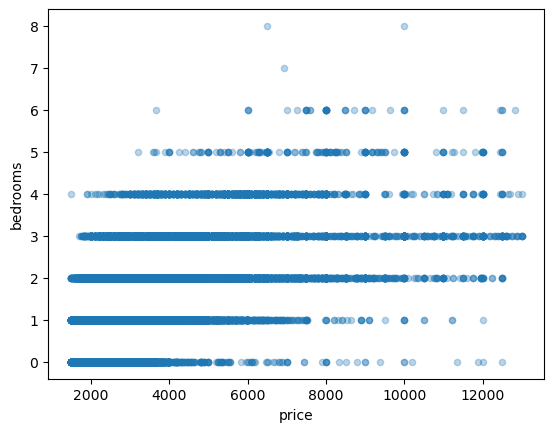

In [144]:
df_no_outliers.plot.scatter(x='price', y='bedrooms',alpha=0.3)
plt.ylabel("bedrooms")
plt.xlabel("price")

Text(0.5, 0, 'price')

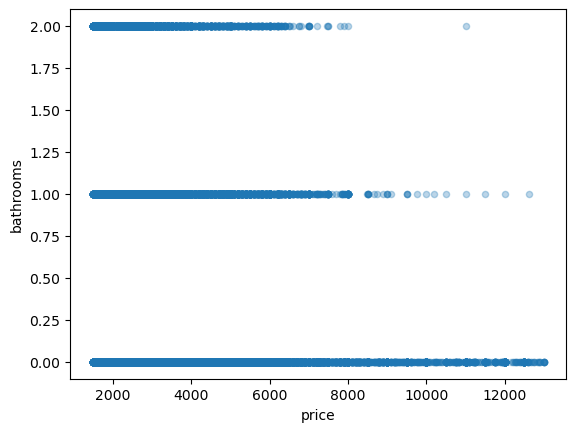

In [145]:
df_no_outliers.plot.scatter(x='price', y='interest_level',alpha=0.3)
plt.ylabel("bathrooms")
plt.xlabel("price")